# 作业一
## 2 概述、线性代数和NDArray 
### 2.1 理论计算题

1.  a与b的点积为-8
2.  AXB的矩阵形状为2X2
3.  向量a的Frobenius范数为√14

### 2.2编程题

In [6]:
import numpy as np

# 为了结果可复现，可以固定随机种子（如不需要可删除）
np.random.seed(42)

# 1) 3x4 标准正态随机矩阵 X
X = np.random.randn(3, 4)


In [7]:
# 2) 4x2 全 1 矩阵 Y
Y = np.ones((4, 2))


In [8]:
# 3) 矩阵乘法 Z = X @ Y
Z = X @ Y

In [9]:

# 打印矩阵
print("X =\n", X)
print("\nY =\n", Y)
print("\nZ =\n", Z)


X =
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z =
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]


In [10]:

# 4) 输出 Z 的第一行第二列元素，以及 Z 的第 2 行所有元素
print("\nZ[0, 1] =", Z[0, 1])
print("Z 第2行所有元素 (Z[1, :]) =", Z[1, :])



Z[0, 1] = 2.5291682463487657
Z 第2行所有元素 (Z[1, :]) = [1.87835721 1.87835721]


In [11]:

# 5) 计算 Frobenius 范数
fro_norm = np.linalg.norm(Z, ord='fro')
print("\nZ 的 Frobenius 范数 =", fro_norm)


Z 的 Frobenius 范数 = 4.616873319476864


## 3 文档2:统计与概率
### 3.1 理论计算题

一个人如果为阳性，他真正的患病概率为P(A|B)=(P(B|A)*P(A))/P(B)=11/233

### 3.2 编程题

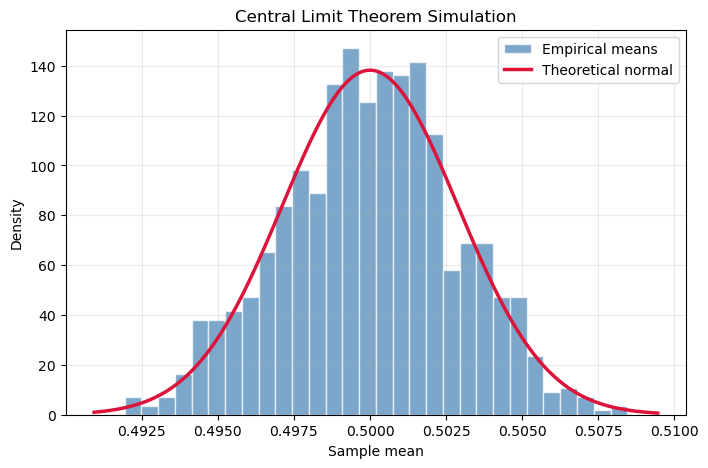

Empirical variance of the 1000 sample means: 0.00000828
Theoretical variance: 0.00000833


In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 10000
m = 1000

# Generate m samples, each sample is the mean of n U(0, 1) variables
samples = np.random.uniform(0.0, 1.0, size=(m, n))
means = samples.mean(axis=1)

# Empirical variance of the sample means
actual_variance = np.var(means, ddof=0)

# Theoretical normal approximation
theoretical_mean = 0.5
theoretical_std = np.sqrt(1.0 / (12.0 * n))
x = np.linspace(means.min() - 0.001, means.max() + 0.001, 400)
normal_pdf = (1.0 / (theoretical_std * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - theoretical_mean) / theoretical_std) ** 2)

plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='white', label='Empirical means')
plt.plot(x, normal_pdf, color='crimson', linewidth=2.5, label='Theoretical normal')
plt.title('Central Limit Theorem Simulation')
plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f'Empirical variance of the 1000 sample means: {actual_variance:.8f}')
print(f'Theoretical variance: {1.0 / (12.0 * n):.8f}')

## 4 文档 3：导数、反向传播和复杂度
### 4.1 理论计算题

1.  4(2w1+w2-3).        
 2(2w1+w2-3).  
2.  [-4,-2]. 

### 4.2 编程题

In [17]:
import torch

# 1. 前向计算：a = x * w1, b = a + w2, L = b^2
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2

print(f'a = {a}')
print(f'b = {b}')
print(f'L = {L}')

# 2. 手动按链式法则计算梯度
# dL/db = 2b
# db/dw2 = 1, db/da = 1, da/dw1 = x
dL_db = 2 * b
dL_dw2 = dL_db * 1
dL_dw1 = dL_db * 1 * x

print(f'manual dL/dw1 = {dL_dw1}')
print(f'manual dL/dw2 = {dL_dw2}')

# 3. 使用 torch.autograd 验证
x_t = torch.tensor(2.0)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print(f'autograd dL/dw1 = {w1_t.grad.item()}')
print(f'autograd dL/dw2 = {w2_t.grad.item()}')

# 4. 一致性检查
print(f'dL/dw1 match: {abs(dL_dw1 - w1_t.grad.item()) < 1e-12}')
print(f'dL/dw2 match: {abs(dL_dw2 - w2_t.grad.item()) < 1e-12}')

a = 3.0
b = 3.5
L = 12.25
manual dL/dw1 = 14.0
manual dL/dw2 = 7.0
autograd dL/dw1 = 14.0
autograd dL/dw2 = 7.0
dL/dw1 match: True
dL/dw2 match: True


## 5 文档 4：线性方法、基础优化和 softmax 回归
### 5.1 理论计算题

对 w 的偏导数：

$$
\frac{\partial L}{\partial w}
= -\frac{2}{n}\sum_{i=1}^{n} x_i\bigl(y_i - (wx_i + b)\bigr)
$$

对 b 的偏导数：

$$
\frac{\partial L}{\partial b}
= -\frac{2}{n}\sum_{i=1}^{n} \bigl(y_i - (wx_i + b)\bigr)
$$

In [18]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 1. 加载数据集
digits = load_digits()
X = digits.data.astype(np.float64) / 16.0
y = digits.target.astype(np.int64)

# 2. 划分训练集和测试集，并进行 one-hot 编码
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
num_classes = 10
Y_train = np.eye(num_classes)[y_train]
Y_test = np.eye(num_classes)[y_test]

# 加上偏置项
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

# 3. 实现 softmax 和交叉熵损失函数

def softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def cross_entropy(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# 4. 小批量随机梯度下降训练
n_features = X_train.shape[1]
W = np.random.normal(0.0, 0.01, size=(n_features, num_classes))
learning_rate = 0.1
batch_size = 32
epochs = 50

for epoch in range(epochs):
    indices = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    for start in range(0, X_train_shuffled.shape[0], batch_size):
        end = start + batch_size
        xb = X_train_shuffled[start:end]
        yb = Y_train_shuffled[start:end]

        logits = xb @ W
        probs = softmax(logits)
        grad = xb.T @ (probs - yb) / xb.shape[0]
        W -= learning_rate * grad

# 5. 评估测试集准确率
train_probs = softmax(X_train @ W)
test_probs = softmax(X_test @ W)
train_loss = cross_entropy(Y_train, train_probs)
test_loss = cross_entropy(Y_test, test_probs)
y_pred = np.argmax(test_probs, axis=1)
accuracy = np.mean(y_pred == y_test)

print(f"训练集损失: {train_loss:.4f}")
print(f"测试集损失: {test_loss:.4f}")
print(f"测试集准确率: {accuracy:.4f}")

训练集损失: 0.1805
测试集损失: 0.1924
测试集准确率: 0.9528


## 6 文档 5：最大似然估计和逻辑回归
### 6.1 理论计算题

**题设**

设样本 $x_1,x_2,\dots,x_n$ 独立同分布于正态分布 $N(\mu,\sigma^2)$，其中 $\mu\in\mathbb R,\ \sigma^2>0$。

单个样本密度为

$$
f(x_i\mid\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right).
$$

**1. 似然函数 $L(\mu,\sigma^2)$**

由独立性，联合密度（即似然函数）为

$$
L(\mu,\sigma^2)=\prod_{i=1}^n f(x_i\mid\mu,\sigma^2)
=\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)^n
\exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2\right).
$$

**2. 证明 $\hat\mu=\frac{1}{n}\sum_{i=1}^n x_i$**

取对数似然：

$$
\ell(\mu,\sigma^2)=\ln L(\mu,\sigma^2)
=-\frac n2\ln(2\pi)-\frac n2\ln\sigma^2-\frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2.
$$

对 $\mu$ 求偏导：

$$
\frac{\partial \ell}{\partial \mu}
=-\frac{1}{2\sigma^2}\cdot \frac{\partial}{\partial\mu}\sum_{i=1}^n(x_i-\mu)^2
=\frac{1}{\sigma^2}\sum_{i=1}^n(x_i-\mu).
$$

令一阶导数为 0：

$$
\sum_{i=1}^n(x_i-\mu)=0
\Longrightarrow n\mu=\sum_{i=1}^n x_i
\Longrightarrow \hat\mu=\frac{1}{n}\sum_{i=1}^n x_i.
$$

二阶导数：

$$
\frac{\partial^2\ell}{\partial\mu^2}=-\frac{n}{\sigma^2}<0,
$$

故该驻点为极大值点，因此 $\hat\mu$ 为最大似然估计。

**3. 证明 $\hat\sigma^2=\frac{1}{n}\sum_{i=1}^n(x_i-\hat\mu)^2$**

对 $\sigma^2$ 求偏导：

$$
\frac{\partial \ell}{\partial \sigma^2}
=-\frac{n}{2\sigma^2}+\frac{1}{2\sigma^4}\sum_{i=1}^n(x_i-\mu)^2.
$$

令其为 0：

$$
-\frac{n}{2\sigma^2}+\frac{1}{2\sigma^4}\sum_{i=1}^n(x_i-\mu)^2=0
\Longrightarrow -n\sigma^2+\sum_{i=1}^n(x_i-\mu)^2=0,
$$

即

$$
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^n(x_i-\mu)^2.
$$

再代入 $\mu=\hat\mu$，得到

$$
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^n(x_i-\hat\mu)^2.
$$

这就是正态分布参数的最大似然估计。

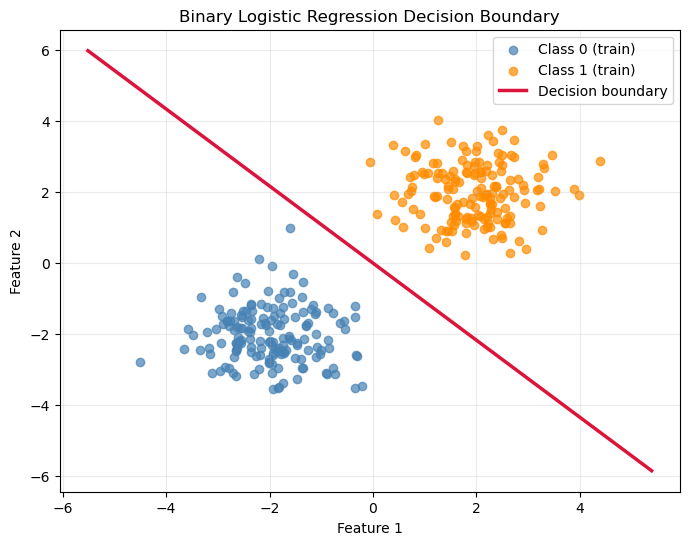

Learned w: [1.98106073 1.82483259]
Learned b: -0.001267
Final training loss: 0.003811
Test accuracy: 1.0000


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)

# 1. 生成两类线性可分数据：每类 200 个样本，特征维度为 2
n_per_class = 200
mean0 = np.array([-2.0, -2.0])
mean1 = np.array([2.0, 2.0])
cov = np.array([[0.6, 0.0], [0.0, 0.6]])

X0 = np.random.multivariate_normal(mean0, cov, n_per_class)
X1 = np.random.multivariate_normal(mean1, cov, n_per_class)
y0 = np.zeros(n_per_class, dtype=np.float64)
y1 = np.ones(n_per_class, dtype=np.float64)

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 新生成 100 个测试样本（每类 50 个）
X0_test = np.random.multivariate_normal(mean0, cov, 50)
X1_test = np.random.multivariate_normal(mean1, cov, 50)
X_test = np.vstack([X0_test, X1_test])
y_test = np.concatenate([np.zeros(50, dtype=np.float64), np.ones(50, dtype=np.float64)])

# 2. 定义 sigmoid 函数和二元交叉熵损失
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred))

# 3. 使用梯度下降法学习参数 w, b
w = np.zeros(X_train.shape[1], dtype=np.float64)
b = 0.0
learning_rate = 0.1
num_iters = 1000
loss_history = []

for i in range(num_iters):
    linear_output = X_train @ w + b
    y_pred = sigmoid(linear_output)

    loss = binary_cross_entropy(y_train, y_pred)
    loss_history.append(loss)

    dw = (X_train.T @ (y_pred - y_train)) / X_train.shape[0]
    db = np.mean(y_pred - y_train)

    w -= learning_rate * dw
    b -= learning_rate * db

# 4. 绘制决策边界
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], alpha=0.7, label='Class 0 (train)', color='steelblue')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], alpha=0.7, label='Class 1 (train)', color='darkorange')

x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
x_line = np.linspace(x_min, x_max, 200)
if abs(w[1]) > 1e-12:
    y_line = -(w[0] * x_line + b) / w[1]
    plt.plot(x_line, y_line, color='crimson', linewidth=2.5, label='Decision boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Logistic Regression Decision Boundary')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 5. 在测试集上计算准确率
test_probs = sigmoid(X_test @ w + b)
test_preds = (test_probs >= 0.5).astype(np.float64)
accuracy = np.mean(test_preds == y_test)

print(f'Learned w: {w}')
print(f'Learned b: {b:.6f}')
print(f'Final training loss: {loss_history[-1]:.6f}')
print(f'Test accuracy: {accuracy:.4f}')